In [1]:
# ============================================
# SECCIÓN 7. CLUSTERING MEDIANTE K-MEANS
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configuración visual
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# --------------------------------------------
# 1. Carga del dataset
# --------------------------------------------
df = sns.load_dataset("penguins").copy()

In [3]:
# --------------------------------------------
# 1. Selección de variables numéricas
# --------------------------------------------
vars_numericas = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df_km = df[vars_numericas + ["species", "sex"]].dropna(subset=vars_numericas).copy()

In [4]:
# --------------------------------------------
# 2. Estandarización
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_km[vars_numericas])

In [5]:
# --------------------------------------------
# 3. Probar varios valores de k
# --------------------------------------------
k_values = range(2, 7)
inercias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

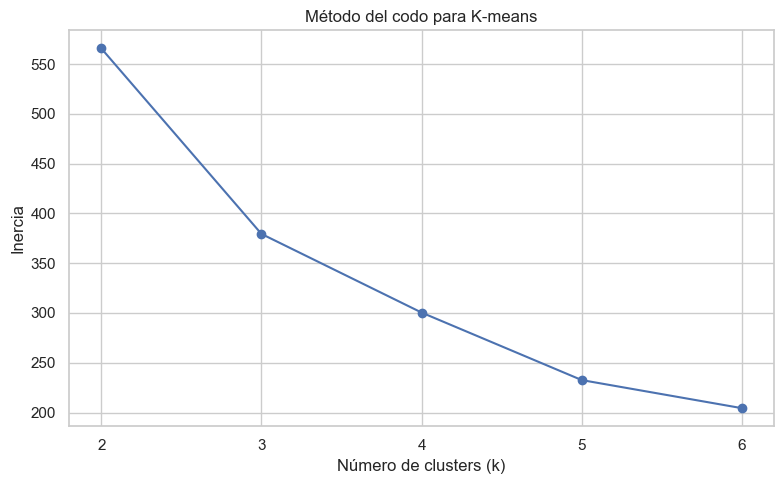

In [6]:
# --------------------------------------------
# 4. Método del codo
# --------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(k_values, inercias, marker="o")
plt.title("Método del codo para K-means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# --------------------------------------------
# 5. Ajuste final del modelo K-means
# Ajusta k según tu criterio (por ejemplo, 3)
# --------------------------------------------
k_final = 3

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_km["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled) + 1  # +1 para etiquetar desde 1

In [8]:
# --------------------------------------------
# 6. Tamaño de los clusters
# --------------------------------------------
print("Frecuencia por cluster K-means:")
display(df_km["cluster_kmeans"].value_counts().sort_index())

Frecuencia por cluster K-means:


cluster_kmeans
1     87
2    123
3    132
Name: count, dtype: int64

In [9]:
# --------------------------------------------
# 7. Centroides en escala estandarizada
# --------------------------------------------
centroides_std = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=vars_numericas,
    index=[f"Cluster {i}" for i in range(1, k_final + 1)]
)

print("Centroides en escala estandarizada:")
display(centroides_std)


Centroides en escala estandarizada:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Cluster 1,0.66,0.82,-0.29,-0.37
Cluster 2,0.66,-1.10,1.16,1.09
Cluster 3,-1.05,0.49,-0.89,-0.77


In [10]:
# --------------------------------------------
# 8. Centroides en escala original
# --------------------------------------------
centroides_original = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_),
    columns=vars_numericas,
    index=[f"Cluster {i}" for i in range(1, k_final + 1)]
)

print("Centroides en escala original:")
display(centroides_original.round(2))

Centroides en escala original:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Cluster 1,47.53,18.76,196.90,"3,902.01"
Cluster 2,47.50,14.98,217.19,"5,076.02"
Cluster 3,38.21,18.11,188.40,"3,584.66"


In [11]:
# --------------------------------------------
# 9. Tabla cruzada con species
# --------------------------------------------
print("Tabla cruzada: cluster K-means vs species")
tabla_kmeans_species = pd.crosstab(
    df_km["cluster_kmeans"],
    df_km["species"],
    margins=True
)
display(tabla_kmeans_species)


Tabla cruzada: cluster K-means vs species


species,Adelie,Chinstrap,Gentoo,All
cluster_kmeans,,,,
1,24,63,0,87
2,0,0,123,123
3,127,5,0,132
All,151,68,123,342


In [12]:
# --------------------------------------------
# 10. Perfil medio de cada cluster
# --------------------------------------------
print("Medias de variables numéricas por cluster K-means:")
perfil_kmeans = (
    df_km.groupby("cluster_kmeans")[vars_numericas]
    .mean()
    .round(2)
)
display(perfil_kmeans)

Medias de variables numéricas por cluster K-means:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
cluster_kmeans,,,,
1,47.53,18.76,196.90,"3,902.01"
2,47.50,14.98,217.19,"5,076.02"
3,38.21,18.11,188.40,"3,584.66"


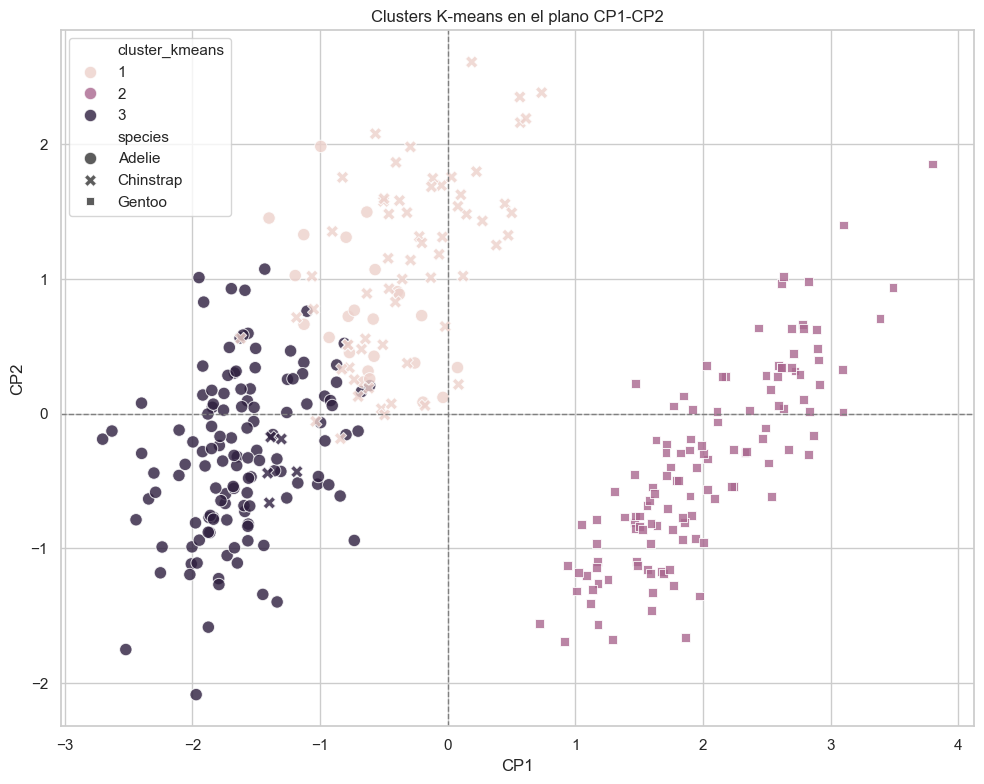

In [13]:
# --------------------------------------------
# 11. Visualización en el plano PCA
# --------------------------------------------
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_scaled)

df_km["CP1"] = X_pca_vis[:, 0]
df_km["CP2"] = X_pca_vis[:, 1]

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df_km,
    x="CP1",
    y="CP2",
    hue="cluster_kmeans",
    style="species",
    s=80,
    alpha=0.8
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Clusters K-means en el plano CP1-CP2")
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# VALIDACIÓN K-MEANS CON COEFICIENTE DE SILUETA
# ============================================

from sklearn.metrics import silhouette_score, silhouette_samples

Silhouette score global por número de clusters:


,k,silhouette_score
0,2,0.53
1,3,0.45
2,4,0.40
3,5,0.38
4,6,0.37


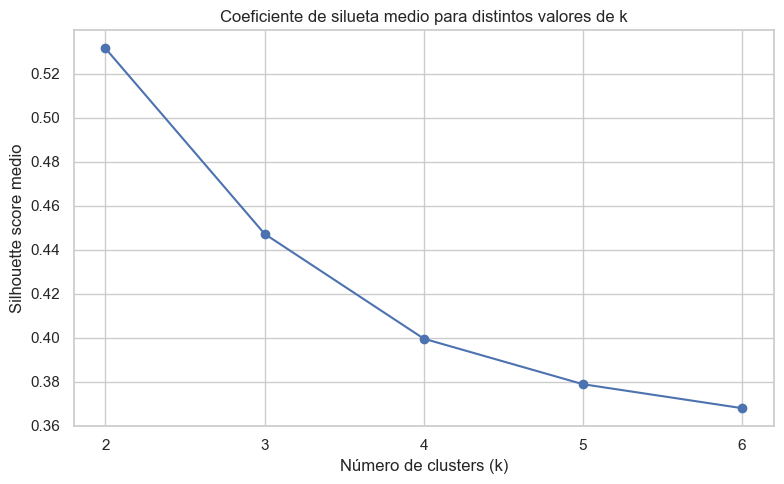

In [15]:
# --------------------------------------------
# 1. Silhouette score global para varios k
# --------------------------------------------
k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, random_state=42)
    silhouette_scores.append(score)

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette_score": silhouette_scores
})

print("Silhouette score global por número de clusters:")
display(silhouette_df)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Coeficiente de silueta medio para distintos valores de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score medio")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# --------------------------------------------
# 2. Silhouette score del modelo final
# --------------------------------------------
# Ojo: silhouette usa etiquetas desde 0 internamente
labels_final = kmeans_final.labels_
silhouette_global_final = silhouette_score(X_scaled, labels_final, random_state=42)

print(f"Silhouette score global del modelo final (k={k_final}): {silhouette_global_final:.4f}")

Silhouette score global del modelo final (k=3): 0.4472


In [17]:
# --------------------------------------------
# 3. Silhouette por observación
# --------------------------------------------
silhouette_vals = silhouette_samples(X_scaled, labels_final)

df_km["silhouette_individual"] = silhouette_vals
df_km["cluster_kmeans_0"] = labels_final  # etiquetas internas 0,1,2,...

print("Primeras observaciones con su coeficiente de silueta:")
display(df_km[["cluster_kmeans", "silhouette_individual"]].head())

Primeras observaciones con su coeficiente de silueta:


,cluster_kmeans,silhouette_individual
0,3,0.49
1,3,0.49
2,3,0.38
4,3,0.49
5,3,0.28


In [18]:
# --------------------------------------------
# 4. Silhouette promedio por cluster
# --------------------------------------------
silhouette_por_cluster = (
    df_km.groupby("cluster_kmeans")["silhouette_individual"]
    .agg(["mean", "min", "max", "count"])
    .round(4)
    .rename(columns={
        "mean": "silueta_media",
        "min": "silueta_min",
        "max": "silueta_max",
        "count": "n_obs"
    })
)

print("Resumen del coeficiente de silueta por cluster:")
display(silhouette_por_cluster)

Resumen del coeficiente de silueta por cluster:


,silueta_media,silueta_min,silueta_max,n_obs
cluster_kmeans,,,,
1,0.30,-0.05,0.54,87
2,0.57,0.32,0.68,123
3,0.43,0.08,0.59,132


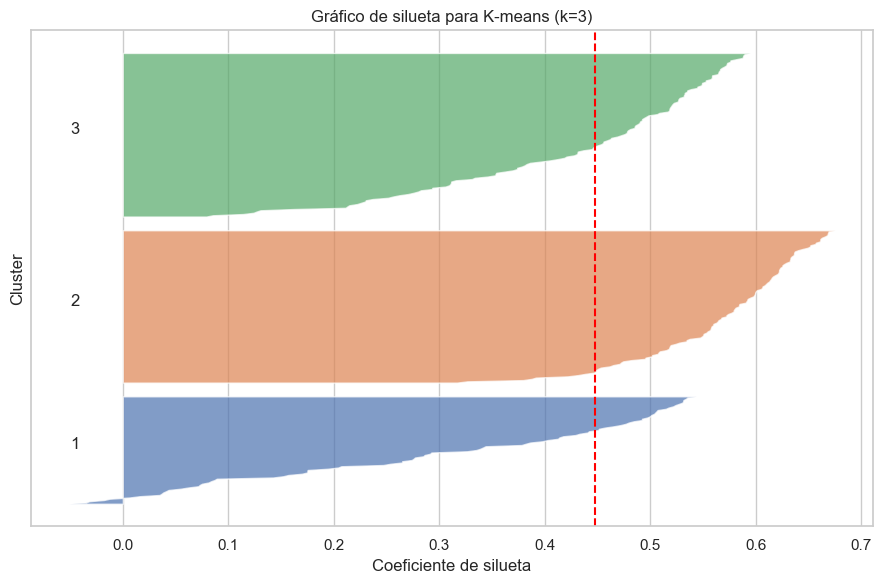

In [19]:
# --------------------------------------------
# 5. Gráfico de silueta del modelo final
# --------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

y_lower = 10
n_clusters = k_final

for i in range(n_clusters):
    vals_cluster = silhouette_vals[labels_final == i]
    vals_cluster.sort()
    size_cluster_i = vals_cluster.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        vals_cluster,
        alpha=0.7
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_global_final, color="red", linestyle="--")
ax.set_title(f"Gráfico de silueta para K-means (k={k_final})")
ax.set_xlabel("Coeficiente de silueta")
ax.set_ylabel("Cluster")
ax.set_yticks([])

plt.tight_layout()
plt.show()

In [20]:
# --------------------------------------------
# 12. Guardar resultados si lo necesitas
# --------------------------------------------
df_km.to_csv("resultados_kmeans.csv", index=False)